In [12]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages
library(data.table)
library(lubridate)
library(janitor)
library(readr)
library(stringr)


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

[1] "datasets"

# I. Load Datasets

In [13]:
#1.. Inheritance Tax data

iht_data = read_csv('/kaggle/input/datasets/geraldalimon/iht-by-pcon/hmrc_iht_by_constituency.csv', show_col_types = FALSE, guess_max = Inf) %>%
    select(
        pcon_name = `Parliamentary Constituency`,
        iht_estates_raw = Number,
        iht_value_million_raw = `Amount (£ million)`
    ) %>%

    #Clean IHT data
    mutate(
        iht_estates = parse_number(
            as.character(iht_estates_raw),
            na = c("", "NA", "N/A", "[c]", "c")
        ),
        iht_value_million = parse_number(
            as.character(iht_value_million_raw),
            na = c("", "NA", "N/A", "[c]", "c")
        )
    ) %>%
    select(
        pcon_name,
        iht_estates,
        iht_value_million
    )

#2. LCON Lookup Data

lookup = read_csv('/kaggle/input/datasets/geraldalimon/lookup-lsoa-to-pcon/LSOA_PCON_LAD_lookup.csv', show_col_types = FALSE, guess_max = Inf) %>% 
    select(
        lsoa_code = LSOA21CD,
        lsoa_name = LSOA21NM,
        pcon_code = PCON24CD,
        pcon_name = PCON24NM,
        lad_code  = LAD21CD,
        lad_name  = LAD21NM
    )

#3. LSOA Population, Age and Sex Data

lsoa_pop = read_csv('/kaggle/input/datasets/geraldalimon/lsoa-population-number-sex-and-age/lsoa_population.csv', show_col_types = FALSE, guess_max = Inf) %>%
    select(
        lad_code  = `LAD 2023 Code`,
        lad_name  = `LAD 2023 Name`,
        lsoa_code = `LSOA 2021 Code`,
        lsoa_name = `LSOA 2021 Name`,
        population = Total,
        starts_with("F"),
        starts_with("M")
    )



In [14]:
#4. Land Registry Sale Data

ppd_raw = fread(
    "/kaggle/input/datasets/geraldalimon/land-registry-data/ppd_data.csv",
    header = FALSE,
    select = c(2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12),
    colClasses = "character"
)

setnames(
    ppd_raw,
    c(
        "price",
        "date_of_transfer",
        "postcode",
        "property_type",
        "old_new",
        "duration",
        "paon",
        "saon",
        "street",
        "locality",
        "town_city"
    )
)

nrow(ppd_raw)
head(ppd_raw$date_of_transfer, 20)

[1] 82937

[1] "2021-10-25 00:00" "2021-11-05 00:00" "2021-11-22 00:00" "2021-11-26 00:00"
 [5] "2021-09-30 00:00" "2021-12-21 00:00" "2021-06-18 00:00" "2021-05-28 00:00"
 [9] "2021-03-26 00:00" "2021-03-12 00:00" "2021-06-11 00:00" "2021-06-29 00:00"
[13] "2021-08-09 00:00" "2021-10-14 00:00" "2021-06-30 00:00" "2021-08-26 00:00"
[17] "2021-06-29 00:00" "2021-06-03 00:00" "2021-04-01 00:00" "2021-12-17 00:00"

In [15]:
ppd_all = ppd_raw %>%
    as_tibble() %>%
    mutate(
        price = as.numeric(price),

        date_of_transfer = parse_date_time(
            str_trim(date_of_transfer),
            orders = c("dmy HM", "dmy HMS", "ymd HM", "ymd HMS", "ymd")
        ),

        year = year(date_of_transfer),

        postcode_key = str_remove_all(str_to_upper(postcode), "\\s+"),

        property_key = paste(
            postcode_key,
            str_squish(str_to_upper(paon)),
            str_squish(str_to_upper(saon)),
            str_squish(str_to_upper(street)),
            sep = "_"
        )
    )

ppd_all %>%
    count(year, sort = TRUE)

year,n
<int>,<int>
2026,45535
2025,32116
2024,2163
2023,713
2022,476
2021,348
2020,202
2019,146
2018,118


In [16]:
ppd_latest = ppd_all %>%
    filter(!is.na(date_of_transfer), !is.na(property_key)) %>%
    group_by(property_key) %>%
    slice_max(date_of_transfer, n = 1, with_ties = FALSE) %>%
    ungroup()

In [17]:
ppd_latest %>%
    count(year, sort = TRUE)

ppd_latest %>%
    select(date_of_transfer, year, price, postcode_key) %>%
    head(20)

year,n
<int>,<int>
2026,45348
2025,31535
2024,2098
2023,677
2022,432
2021,302
2020,172
2019,108
2018,82


date_of_transfer,year,price,postcode_key
<dttm>,<int>,<dbl>,<chr>
2025-10-01,2025,180000,AL100AZ
2025-08-01,2025,585000,AL100DB
2025-09-16,2025,440000,AL100DU
2026-03-31,2026,405000,AL100DZ
2026-04-02,2026,185000,AL100EF
2026-03-11,2026,360000,AL100JG
2026-03-10,2026,127000,AL100LZ
2026-03-26,2026,135000,AL100NA
2026-03-26,2026,375000,AL100PU


In [18]:
#5.. National Statistics Postcode Lookup

nspl_path = "/kaggle/input/datasets/geraldalimon/national-statistics-postcode-lookup/NSPL_MAY_2025_UK.csv"

nspl = fread(
    nspl_path,
    select = c("pcds", "laua"),
    colClasses = "character"
) %>%
    as_tibble() %>%
    transmute(
        postcode_key = str_remove_all(str_to_upper(pcds), "\\s+"),
        lad_code = laua
    ) %>%
    distinct(postcode_key, .keep_all = TRUE)

In [19]:
#6. LSOA 5 year Death Registration for Males and Females

male_deaths_raw = read_csv(
  "/kaggle/input/datasets/geraldalimon/lsoa-5-year-death-reg-males/Death registrations (males) by five-year age bands by Lower Layer Output Area (LSOA) in England and Wales 2001 to 2023.csv",
  show_col_types = FALSE,
  guess_max = Inf
) %>%
  clean_names() %>%
  mutate(sex = "Male")

female_deaths_raw = read_csv(
  "/kaggle/input/datasets/geraldalimon/lsoa-5-year-deaths-reg-females/Death registrations (females) by five-year age bands by Lower Layer Output Area (LSOA) in England and Wales 2001 to 2023.csv",
  show_col_types = FALSE,
  guess_max = Inf
) %>%
  clean_names() %>%
  mutate(sex = "Female")

#Combine
deaths_raw = bind_rows(
  male_deaths_raw,
  female_deaths_raw
    )


In [20]:
#7. UK House Price Index - Average Price per Property Type - Local Authority Level


ukhpi_property_raw = read_csv(
  "/kaggle/input/datasets/geraldalimon/uk-house-price-index-average-price-property-type/Average-prices-Property-Type-2025-07.csv",
  show_col_types = FALSE
) %>%
  clean_names()

names(ukhpi_property_raw)

[1] "date"                         "region_name"                 
 [3] "area_code"                    "detached_average_price"      
 [5] "detached_index"               "detached_monthly_change"     
 [7] "detached_annual_change"       "semi_detached_average_price" 
 [9] "semi_detached_index"          "semi_detached_monthly_change"
[11] "semi_detached_annual_change"  "terraced_average_price"      
[13] "terraced_index"               "terraced_monthly_change"     
[15] "terraced_annual_change"       "flat_average_price"          
[17] "flat_index"                   "flat_monthly_change"         
[19] "flat_annual_change"

# II. Calculate the weights

Inheritance Tax (IHT) on Parliamentary Constituency (PCON) level
allocated to Local Authority District (LAD) based on population.

PCON and LAD sometimes overlap and boundaries rarely align perfectly.
A simple 1 to 1 join would not be representative.
For proportional allocation to work,
IHT values would be split depending on how much of the constituency falls into each LA (population weighted).

Logic:
If 80% of Constituency A's population lives in Local Authority X, you allocate 80% of Constituency A's IHT to Local Authority X.


In [21]:
#1. Join population to the geographic lookup

age_sex_cols = names(lsoa_pop) %>%
    keep(~ grepl("^[FM][0-9]+$", .x))

geo_weights = lookup %>%
    inner_join(
        lsoa_pop %>%
            select(lsoa_code, population, all_of(age_sex_cols)),
        by = "lsoa_code"
    ) %>%

    #b. Group by PCON to get the total population
    group_by(pcon_code) %>%
    mutate(pcon_total_pop = sum(population, na.rm = TRUE)) %>%
    ungroup() %>%

    #c. Group by the intersection of PCON and LAD
    group_by(pcon_code, pcon_name, lad_code, lad_name) %>%
    summarise(
        intersection_pop = sum(population, na.rm = TRUE),
        pcon_total_pop = first(pcon_total_pop),

        # Keep sex and age columns
        across(
            all_of(age_sex_cols),
            ~ sum(.x, na.rm = TRUE)
        ),

        .groups = "drop"
    ) %>%

    #Calculae the vital percentage: What % of PCON lives in this LAD
    mutate(allocation_weight = intersection_pop / pcon_total_pop)

In [22]:
#2. Add PCON24 code to IHT data using constituency name
pcon_lookup = lookup %>%
    distinct(pcon_code, pcon_name) %>%
    mutate(
        pcon_name_clean = str_squish(str_to_upper(pcon_name))
    ) %>%
    select(pcon_code, pcon_name_clean)

iht_data = iht_data %>%
    mutate(
        pcon_name_clean = str_squish(str_to_upper(pcon_name))
    ) %>%
    left_join(pcon_lookup, by = "pcon_name_clean")

In [23]:
#3.b. (Optional) Check if matching works, should return zero rows

#iht_data %>%
   #filter(is.na(pcon_code)) %>%
    #select(pcon_name)

In [24]:
#4. Allocate and Aggregate

# Apply those weights to the actual tax data

age_sex_cols = names(geo_weights) %>%
    keep(~ grepl("^[FM][0-9]+$", .x))

lad_iht_estimates = geo_weights %>%
    inner_join(iht_data, by = "pcon_code") %>%
  
    mutate(
        allocated_iht_estates = iht_estates * allocation_weight,
        allocated_iht_value_million = iht_value_million * allocation_weight
    ) %>%
  
    group_by(lad_code, lad_name) %>%
    summarise(
        population = sum(intersection_pop, na.rm = TRUE),

        across(
            all_of(age_sex_cols),
            ~ sum(.x, na.rm = TRUE)
        ),

        est_iht_estates_total = sum(allocated_iht_estates, na.rm = TRUE),
        est_iht_value_million_total = sum(allocated_iht_value_million, na.rm = TRUE),

        .groups = "drop"
    )

In [25]:
safe_max = function(x) {
    if (all(is.na(x))) NA_real_ else max(x, na.rm = TRUE)
}

safe_median = function(x) {
    if (all(is.na(x))) NA_real_ else median(x, na.rm = TRUE)
}

In [26]:
housing_lad = ppd_latest %>%
    inner_join(nspl, by = "postcode_key") %>%
    group_by(lad_code) %>%
    summarise(
        median_latest_sale_price = median(price, na.rm = TRUE),
        mean_latest_sale_price = mean(price, na.rm = TRUE),
        unique_properties_sold = n(),

        detached_properties = sum(property_type == "D", na.rm = TRUE),
        semi_detached_properties = sum(property_type == "S", na.rm = TRUE),
        terraced_properties = sum(property_type == "T", na.rm = TRUE),
        flat_properties = sum(property_type == "F", na.rm = TRUE),

        newbuild_properties = sum(old_new == "Y", na.rm = TRUE),
        freehold_properties = sum(duration == "F", na.rm = TRUE),
        leasehold_properties = sum(duration == "L", na.rm = TRUE),

        latest_sale_year_median = safe_median(year),
        latest_sale_year_max = safe_max(year),

        .groups = "drop"
    )

In [27]:
lad_iht_eda = lad_iht_estimates %>%
  mutate(
    iht_value_per_capita = (est_iht_value_million_total * 1e6) / population,
    iht_estates_per_10k = (est_iht_estates_total / population) * 10000,
    avg_iht_value_per_estate = (est_iht_value_million_total * 1e6) / est_iht_estates_total
  )

In [28]:
#Reshape Age Bands into longer ranges
#ONS age bands are short, and deaths per LSOA are relatavely low

deaths_long = deaths_raw %>%
  rename(
    lsoa_code = matches("lsoa.*code|lsoa21cd"),
    lsoa_name = matches("lsoa.*name|lsoa21nm")
  ) %>%
  pivot_longer(
    cols = -c(lsoa_code, lsoa_name, sex),
    names_to = "age_band",
    values_to = "deaths"
  ) %>%
  mutate(
    deaths = parse_number(as.character(deaths))
  ) %>%
  filter(!is.na(deaths))

In [29]:
#Convert 5 year, deaths age bands into age midpoints

deaths_long = deaths_long %>%
  mutate(
    age_band_clean = str_replace_all(age_band, "_", "-"),
    age_band_clean = str_replace_all(age_band_clean, "plus", "+"),
    age_band_clean = str_replace_all(age_band_clean, "and-over|and_over|over", "+"),

    age_midpoint = case_when(
      str_detect(age_band_clean, "^0$|under.*1") ~ 0,
      str_detect(age_band_clean, "1-4") ~ 2.5,
      str_detect(age_band_clean, "5-9") ~ 7,
      str_detect(age_band_clean, "10-14") ~ 12,
      str_detect(age_band_clean, "15-19") ~ 17,
      str_detect(age_band_clean, "20-24") ~ 22,
      str_detect(age_band_clean, "25-29") ~ 27,
      str_detect(age_band_clean, "30-34") ~ 32,
      str_detect(age_band_clean, "35-39") ~ 37,
      str_detect(age_band_clean, "40-44") ~ 42,
      str_detect(age_band_clean, "45-49") ~ 47,
      str_detect(age_band_clean, "50-54") ~ 52,
      str_detect(age_band_clean, "55-59") ~ 57,
      str_detect(age_band_clean, "60-64") ~ 62,
      str_detect(age_band_clean, "65-69") ~ 67,
      str_detect(age_band_clean, "70-74") ~ 72,
      str_detect(age_band_clean, "75-79") ~ 77,
      str_detect(age_band_clean, "80-84") ~ 82,
      str_detect(age_band_clean, "85-89") ~ 87,
      str_detect(age_band_clean, "90") ~ 92,
      TRUE ~ NA_real_
    )
  ) %>%
  filter(!is.na(age_midpoint))

In [30]:
# Calculate average age during death and typical sex during death per LSOA

death_profile_lsoa = deaths_long %>%
  group_by(lsoa_code, lsoa_name) %>%
  summarise(
    total_deaths = sum(deaths, na.rm = TRUE),

    avg_age_at_death = weighted.mean(
      age_midpoint,
      deaths,
      na.rm = TRUE
    ),

    male_deaths = sum(deaths[sex == "Male"], na.rm = TRUE),
    female_deaths = sum(deaths[sex == "Female"], na.rm = TRUE),

    .groups = "drop"
  ) %>%
  mutate(
    male_death_share = male_deaths / total_deaths,
    female_death_share = female_deaths / total_deaths,

    typical_death_sex = case_when(
      male_death_share > female_death_share ~ "Male",
      female_death_share > male_death_share ~ "Female",
      TRUE ~ "Equal"
    )
  )

In [31]:
#Join deaths profile to Local Authority District geography

death_profile_lad = death_profile_lsoa %>%
  left_join(
    lookup %>%
      select(lsoa_code, lad_code, lad_name) %>%
      distinct(),
    by = "lsoa_code"
  ) %>%
  group_by(lad_code, lad_name) %>%
  summarise(
    lad_total_deaths = sum(total_deaths, na.rm = TRUE),

    avg_age_at_death = sum(avg_age_at_death * total_deaths, na.rm = TRUE) /
      sum(total_deaths[!is.na(avg_age_at_death)], na.rm = TRUE),

    male_deaths = sum(male_deaths, na.rm = TRUE),
    female_deaths = sum(female_deaths, na.rm = TRUE),

    .groups = "drop"
  ) %>%
  mutate(
    male_death_share = male_deaths / lad_total_deaths,
    female_death_share = female_deaths / lad_total_deaths,

    typical_death_sex = case_when(
      male_death_share > female_death_share ~ "Male",
      female_death_share > male_death_share ~ "Female",
      TRUE ~ "Equal"
    )
  )

In [32]:
# Join deaths profile with IHT data

iht_death_eda = lad_iht_estimates %>%
  left_join(death_profile_lad, by = c("lad_code", "lad_name")) %>%
  mutate(
    iht_value_per_capita = (est_iht_value_million_total * 1e6) / population,
    iht_estates_per_10k = (est_iht_estates_total / population) * 10000,
    log_iht_value_per_capita = log1p(iht_value_per_capita)
  )

In [33]:
#Check before EDA

iht_death_eda %>%
  select(
    lad_code,
    lad_name,
    est_iht_value_million_total,
    iht_value_per_capita,
    lad_total_deaths,
    avg_age_at_death,
    male_death_share,
    female_death_share,
    typical_death_sex
  ) %>%
  glimpse()

Rows: 292
Columns: 9
$ lad_code                    <chr> "E06000001", "E06000002", "E06000003", "E0…
$ lad_name                    <chr> "Hartlepool", "Middlesbrough", "Redcar and…
$ est_iht_value_million_total <dbl> 0.000000, 0.000000, 0.000000, 0.000000, 0.…
$ iht_value_per_capita        <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.0000…
$ lad_total_deaths            <dbl> 22214, 31803, 33384, 39677, 24503, 41609, …
$ avg_age_at_death            <dbl> 74.89637, 74.52932, 75.63617, 75.12385, 76…
$ male_death_share            <dbl> 0.5040965, 0.5024054, 0.5015876, 0.5029614…
$ female_death_share          <dbl> 0.4959035, 0.4975946, 0.4984124, 0.4970386…
$ typical_death_sex           <chr> "Male", "Male", "Male", "Male", "Female", …


Now comparison can be made with:

1. IHT value per capita
2. IHT estates per 10k people
3. average age at death
4. male death share
5. female death share
6. typical death sex


# Exploratory Data Analysis

# 1. IHT comparison by age at death and sex

`geom_smooth()` using formula = 'y ~ x'


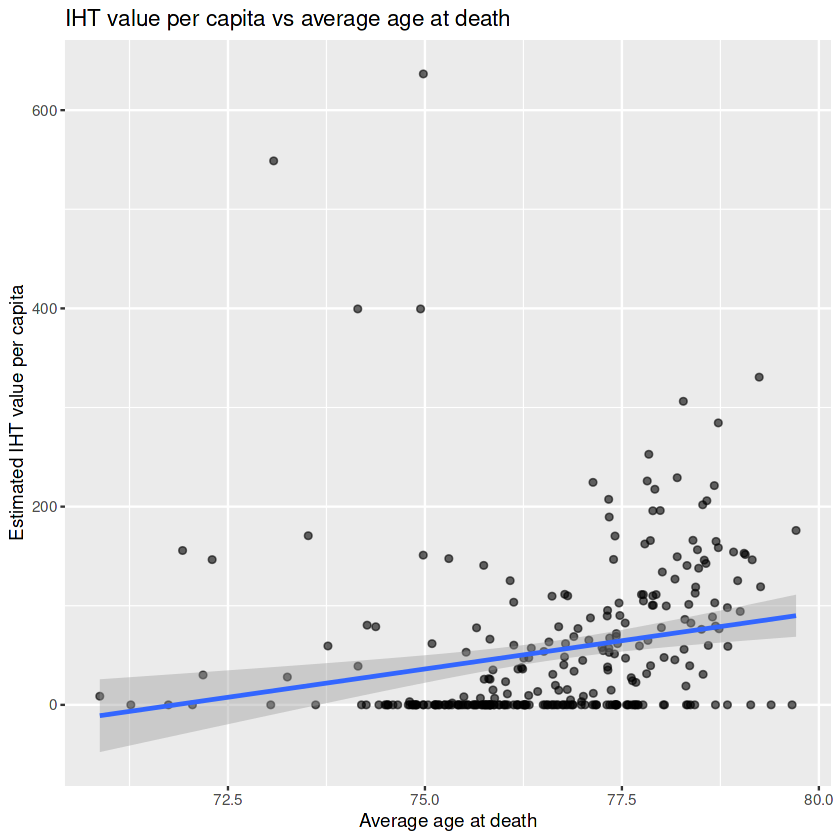

In [34]:
#IHT vs average age at death

ggplot(iht_death_eda, aes(x = avg_age_at_death, y = iht_value_per_capita)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "IHT value per capita vs average age at death",
    x = "Average age at death",
    y = "Estimated IHT value per capita"
  )

There is a expected upward trend with IHT values and age.

However, you can also see the effect of the extreme outliers in the IHT values.

`geom_smooth()` using formula = 'y ~ x'


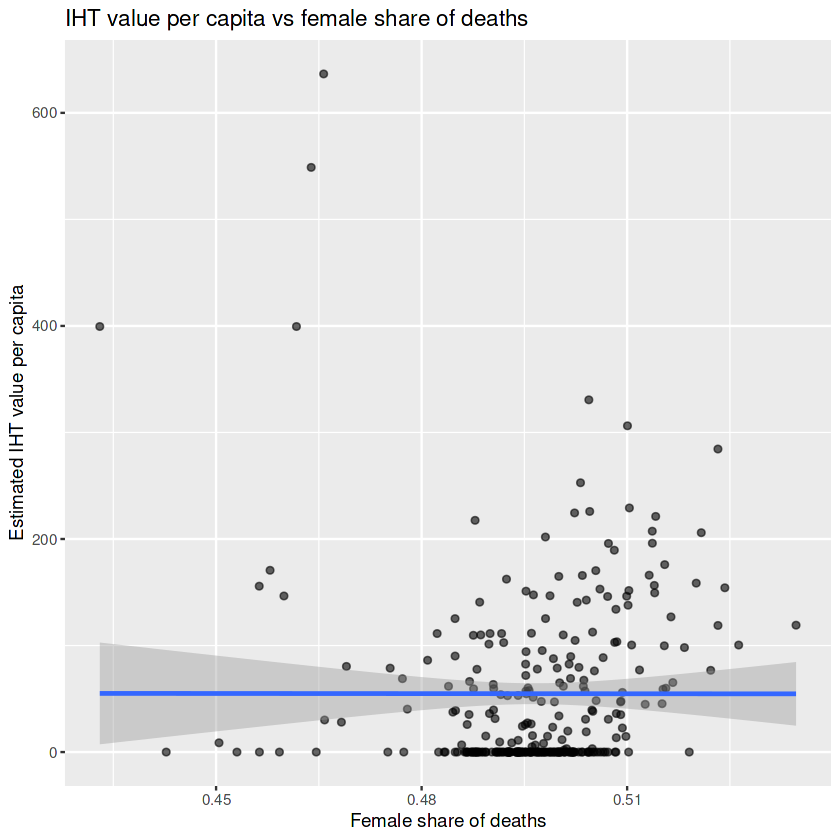

In [35]:
#IHT vs female deaths share

ggplot(iht_death_eda, aes(x = female_death_share, y = iht_value_per_capita)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "IHT value per capita vs female share of deaths",
    x = "Female share of deaths",
    y = "Estimated IHT value per capita"
  )

`geom_smooth()` using formula = 'y ~ x'


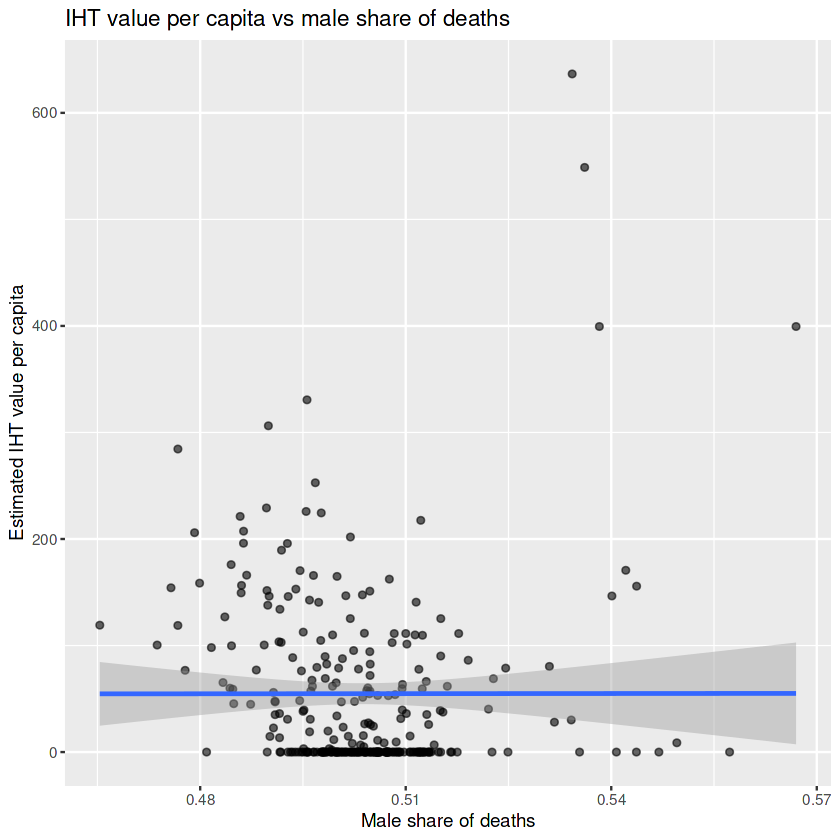

In [36]:
#IHT vs male share of deaths

ggplot(iht_death_eda, aes(x = male_death_share, y = iht_value_per_capita)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "IHT value per capita vs male share of deaths",
    x = "Male share of deaths",
    y = "Estimated IHT value per capita"
  )

Charts summary:

At LAD level, the male/female share of registered deaths does not show a clear relationship with estimated IHT value per capita.

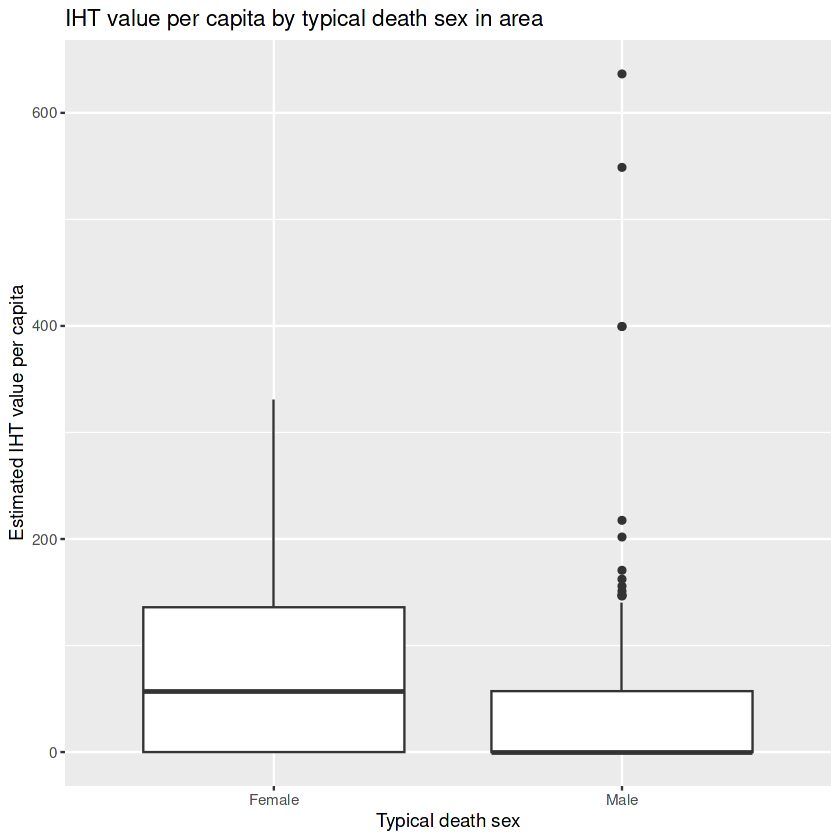

In [37]:
#IHT vs typical sex during death in area

ggplot(iht_death_eda, aes(x = typical_death_sex, y = iht_value_per_capita)) +
  geom_boxplot() +
  labs(
    title = "IHT value per capita by typical death sex in area",
    x = "Typical death sex",
    y = "Estimated IHT value per capita"
  )

Chart summary:

Areas where female deaths are more common appear to have a higher typical IHT value per capita, but some male-dominant death areas have extremely high IHT values.

Log scale needed to reduce dominance of high outliers and to show middle and lower values much clearly.

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 134 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


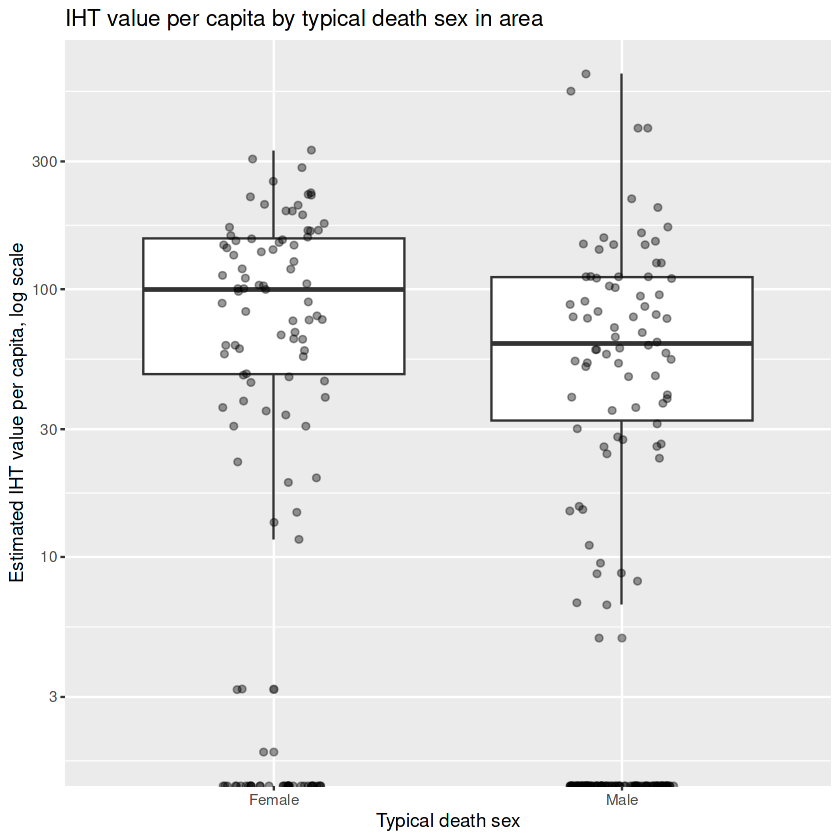

In [38]:
#Plot with Log scale 

ggplot(iht_death_eda, aes(x = typical_death_sex, y = iht_value_per_capita)) +
  geom_boxplot(outlier.alpha = 0.5) +
  geom_jitter(width = 0.15, alpha = 0.4) +
  scale_y_log10() +
  labs(
    title = "IHT value per capita by typical death sex in area",
    x = "Typical death sex",
    y = "Estimated IHT value per capita, log scale"
  )

Chart summary:

Female-dominant death areas show a somewhat higher median IHT value per capita, but the overlap between groups is large.

Typical sex on death may be associated with IHT value per capita, but there may be other factors that contribute to this trend such as longer female life expectancy (they inherit the spouses assests) and house price.



# 2. IHT vs Land Registry Sale

In [39]:
# Join data

iht_land_eda = lad_iht_estimates %>%
  left_join(housing_lad, by = "lad_code")

# Check data (optional)

#glimpse(iht_land_eda)

#iht_land_eda %>%
  #summarise(
    #n_lads = n(),
    #missing_iht = sum(is.na(est_iht_value_million_total)),
    #missing_sale_price = sum(is.na(median_latest_sale_price)),
    #missing_mean_sale_price = sum(is.na(mean_latest_sale_price))
  #)

In [40]:
#Creat per-capita and per-estate measure

iht_land_eda = iht_land_eda %>%
  mutate(
    iht_value_total = est_iht_value_million_total * 1e6,

    iht_value_per_capita = iht_value_total / population,
    iht_estates_per_10k = (est_iht_estates_total / population) * 10000,
    avg_iht_value_per_estate = iht_value_total / est_iht_estates_total,

    log_iht_value_per_capita = log1p(iht_value_per_capita),
    log_iht_estates_per_10k = log1p(iht_estates_per_10k),
    log_median_sale_price = log(median_latest_sale_price),
    log_mean_sale_price = log(mean_latest_sale_price)
  )

In [41]:
#Summary

iht_land_eda %>%
  summarise(
    n_lads = n(),

    median_iht_pc = median(iht_value_per_capita, na.rm = TRUE),
    mean_iht_pc = mean(iht_value_per_capita, na.rm = TRUE),
    max_iht_pc = max(iht_value_per_capita, na.rm = TRUE),

    median_sale_price = median(median_latest_sale_price, na.rm = TRUE),
    mean_sale_price = mean(median_latest_sale_price, na.rm = TRUE),
    max_sale_price = max(median_latest_sale_price, na.rm = TRUE)
  )

n_lads,median_iht_pc,mean_iht_pc,max_iht_pc,median_sale_price,mean_sale_price,max_sale_price
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
292,12.5472,54.80093,636.5423,290000,320046.3,1065000


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 11 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”


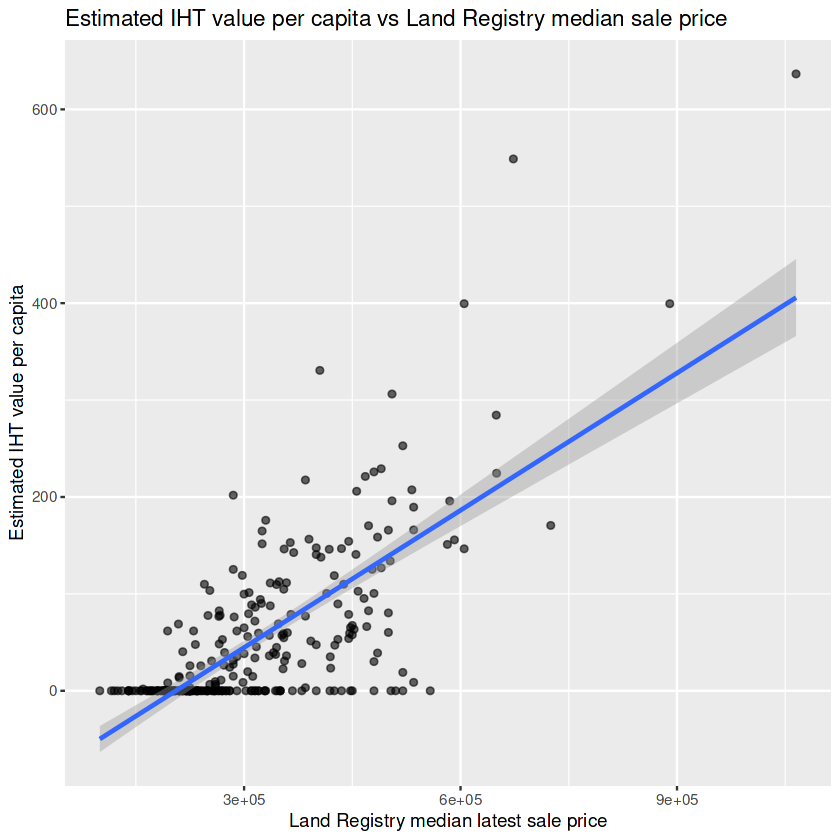

In [42]:
ggplot(iht_land_eda, aes(x = median_latest_sale_price, y = iht_value_per_capita)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Estimated IHT value per capita vs Land Registry median sale price",
    x = "Land Registry median latest sale price",
    y = "Estimated IHT value per capita"
  )

Chart Summary:

The scatterplot shows a positive association between Land Registry median sale price and estimated IHT value per capita at LAD (Local Authority District) level. 

Areas with higher median sale prices generally have higher IHT value per capita, suggesting that local property values may be linked to IHT exposure.

However, there is substantial variation, and several LADs report low or zero IHT despite moderate house prices. This indicates that sale price alone does not fully explain IHT patterns. This suggests that IHT has features independent from house prices.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 11 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”


[1] 0.6767325

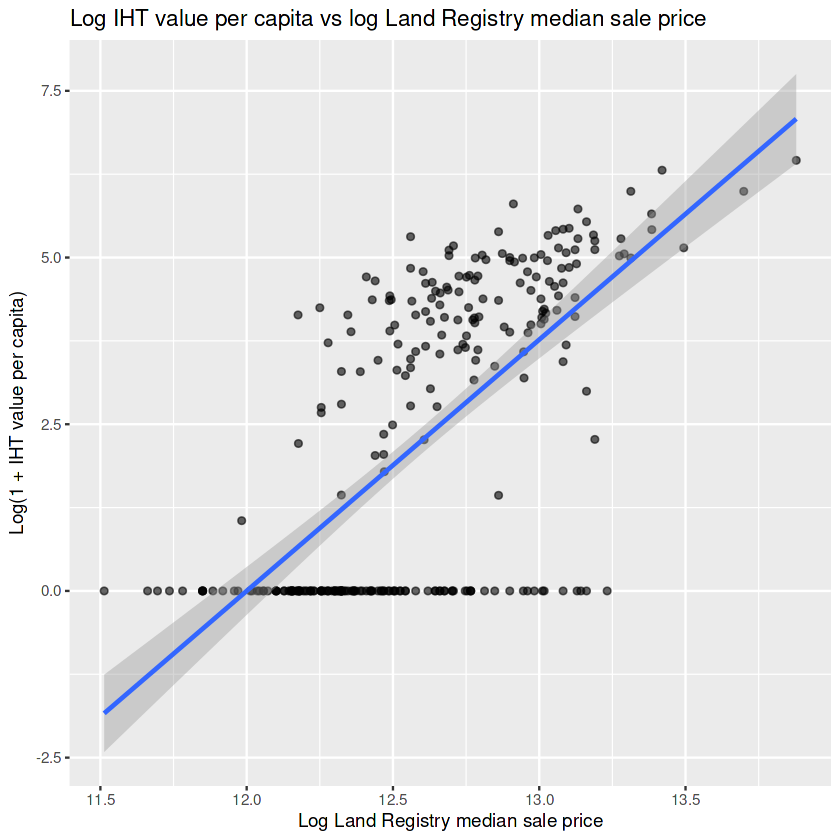

In [43]:
#Log version to reduce influence of very high IHT and house price from Land reg sale

ggplot(iht_land_eda, aes(x = log_median_sale_price, y = log_iht_value_per_capita)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Log IHT value per capita vs log Land Registry median sale price",
    x = "Log Land Registry median sale price",
    y = "Log(1 + IHT value per capita)"
  )

cor(
  iht_land_eda$median_latest_sale_price,
  iht_land_eda$iht_value_per_capita,
  use = "complete.obs",
  method = "spearman"
)

Chart summary:

Log plot gives clearer verion of the previous result.

Local Authority Districts (LAD) with higher Land Registry median sale prices tend to have higher estimated IHT value per capita.

But again, many LADs still have zero or very low estimated IHT values across a range of house prices, indicating that house prices alone do not fully explain IHT patterns.

# 3. IHT vs UK House Price Index

In [44]:
names(ukhpi_property_raw)

[1] "date"                         "region_name"                 
 [3] "area_code"                    "detached_average_price"      
 [5] "detached_index"               "detached_monthly_change"     
 [7] "detached_annual_change"       "semi_detached_average_price" 
 [9] "semi_detached_index"          "semi_detached_monthly_change"
[11] "semi_detached_annual_change"  "terraced_average_price"      
[13] "terraced_index"               "terraced_monthly_change"     
[15] "terraced_annual_change"       "flat_average_price"          
[17] "flat_index"                   "flat_monthly_change"         
[19] "flat_annual_change"

In [45]:
#Clean UKHPI data

ukhpi_property_lad = ukhpi_property_raw %>%
  clean_names() %>%
  transmute(
    hpi_date = dmy(date),
    lad_code = area_code,
    ukhpi_area_name = region_name,

    ukhpi_detached_price = as.numeric(detached_average_price),
    ukhpi_semi_price = as.numeric(semi_detached_average_price),
    ukhpi_terraced_price = as.numeric(terraced_average_price),
    ukhpi_flat_price = as.numeric(flat_average_price)
  ) %>%
  filter(!is.na(lad_code), !is.na(hpi_date))

In [46]:
#Keep latest record per Local Authority District

ukhpi_property_latest = ukhpi_property_lad %>%
  group_by(lad_code) %>%
  slice_max(hpi_date, n = 1, with_ties = FALSE) %>%
  ungroup()

In [47]:
#Check date formats

summary(ukhpi_property_lad$hpi_date)
head(ukhpi_property_lad$hpi_date)
tail(ukhpi_property_lad$hpi_date)

Min.      1st Qu.       Median         Mean      3rd Qu.         Max. 
"1995-01-01" "2003-03-01" "2010-09-01" "2010-07-19" "2018-02-01" "2025-07-01"

[1] "1995-01-01" "1995-01-01" "1995-01-01" "1995-01-01" "1995-01-01"
[6] "1995-01-01"

[1] "2025-07-01" "2025-07-01" "2025-07-01" "2025-07-01" "2025-07-01"
[6] "2025-07-01"

In [48]:
#Join UKHPI with IHT

iht_ukhpi_property_eda = lad_iht_estimates %>%
  left_join(ukhpi_property_latest, by = "lad_code") %>%
  mutate(
    iht_value_total = est_iht_value_million_total * 1e6,
    iht_value_per_capita = iht_value_total / population,
    log_iht_value_per_capita = log1p(iht_value_per_capita),

    log_ukhpi_detached_price = log(ukhpi_detached_price),
    log_ukhpi_semi_price = log(ukhpi_semi_price),
    log_ukhpi_terraced_price = log(ukhpi_terraced_price),
    log_ukhpi_flat_price = log(ukhpi_flat_price)
  )

# 4. Correlation between IHT and House Property Type price (UKHPI)

In [49]:
iht_ukhpi_property_eda %>%
  select(
    iht_value_per_capita,
    ukhpi_detached_price,
    ukhpi_semi_price,
    ukhpi_terraced_price,
    ukhpi_flat_price
  ) %>%
  cor(use = "pairwise.complete.obs", method = "spearman") %>%
  round(2)

,iht_value_per_capita,ukhpi_detached_price,ukhpi_semi_price,ukhpi_terraced_price,ukhpi_flat_price
iht_value_per_capita,1.00,0.67,0.66,0.65,0.65
ukhpi_detached_price,0.67,1.00,0.99,0.99,0.98
ukhpi_semi_price,0.66,0.99,1.00,1.00,0.99
ukhpi_terraced_price,0.65,0.99,1.00,1.00,0.99
ukhpi_flat_price,0.65,0.98,0.99,0.99,1.00


Table Summary:

IHT value per capita is positively related to all UKHPI property-type prices:


*detached: 0.67 / semi-detached: 0.66 / terraced: 0.65 / flat: 0.65*


Local Authority Districts with higher UKHPI prices tend to have higher IHT value per capita, regardless of property type.

UKHPI property-type prices are almost perfectly correlated with each other:


*detached vs semi: 0.99 / semi vs terraced: 1.00 / terraced vs flat: 0.99*


This means that the four variables measure the same factor, which is how expensive the local properties are.

However, it also shows that the UKHPI property-type variables are not distinct enough to be interpreted independently.

# 5. IHT vs Detached House Price (UKHPI)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 15 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”


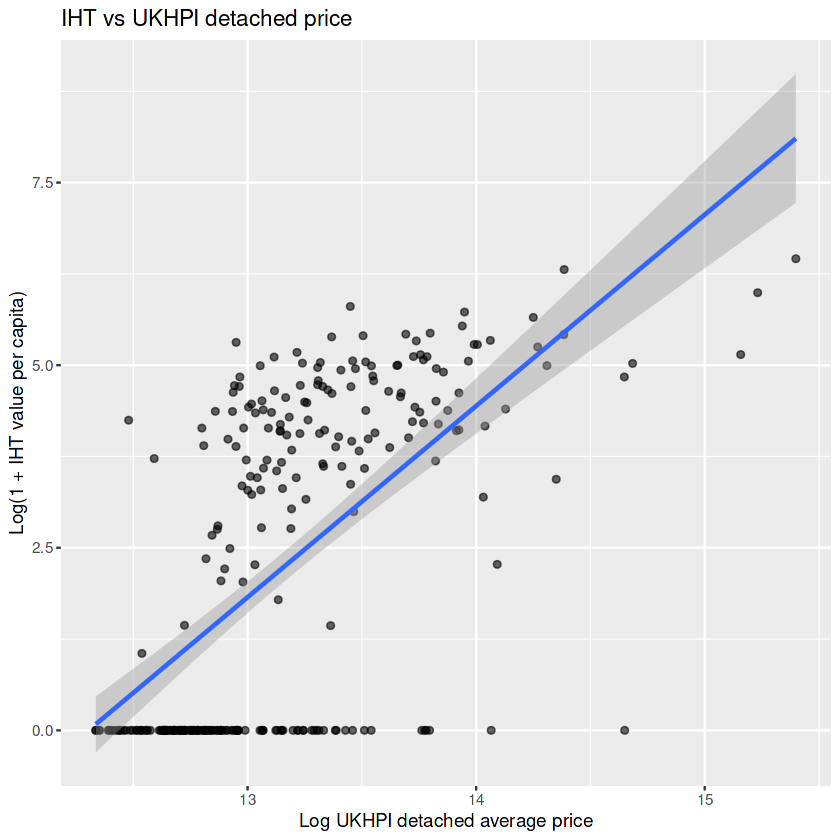

In [50]:
ggplot(iht_ukhpi_property_eda, aes(x = log_ukhpi_detached_price, y = log_iht_value_per_capita)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "IHT vs UKHPI detached price",
    x = "Log UKHPI detached average price",
    y = "Log(1 + IHT value per capita)"
  )

# 6. IHT vs House prices by property types (UKHPI)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 59 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”


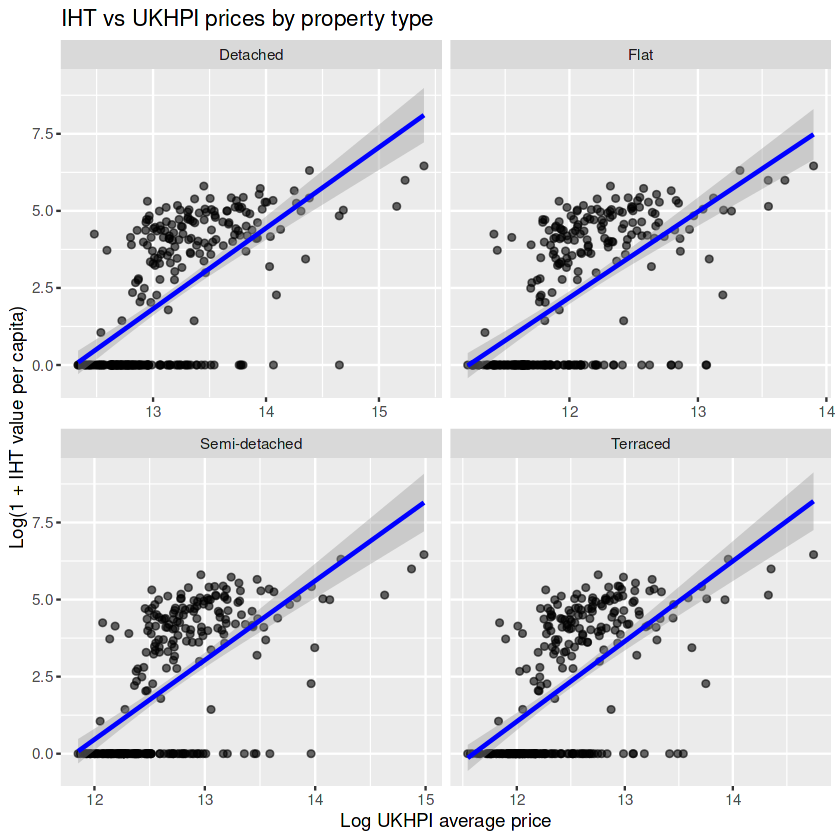

In [51]:
iht_ukhpi_long = iht_ukhpi_property_eda %>%
  select(
    lad_code,
    lad_name,
    log_iht_value_per_capita,
    ukhpi_detached_price,
    ukhpi_semi_price,
    ukhpi_terraced_price,
    ukhpi_flat_price
  ) %>%
  pivot_longer(
    cols = c(
      ukhpi_detached_price,
      ukhpi_semi_price,
      ukhpi_terraced_price,
      ukhpi_flat_price
    ),
    names_to = "property_type",
    values_to = "ukhpi_price"
  ) %>%
  mutate(
    log_ukhpi_price = log(ukhpi_price),
    property_type = recode(
      property_type,
      ukhpi_detached_price = "Detached",
      ukhpi_semi_price = "Semi-detached",
      ukhpi_terraced_price = "Terraced",
      ukhpi_flat_price = "Flat"
    )
  )

ggplot(iht_ukhpi_long, aes(x = log_ukhpi_price, y = log_iht_value_per_capita)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  facet_wrap(~ property_type, scales = "free_x") +
  labs(
    title = "IHT vs UKHPI prices by property type",
    x = "Log UKHPI average price",
    y = "Log(1 + IHT value per capita)"
  )



Chart Summary:

In the Local Authority District level, areas with more expensive houses tend to have higher estimated IHT value per capita.

Areas with low houses prices tend to have low or zero IHT.
Consequently, areas with higher house prices tend to have higher IHT.

This pattern is consistent for all property types.

This suggest that property types show a similar positive relationship with IHT, with detached slightly strongest, but the overall differences are small.

# 7. House price vs Sex share

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 11 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”


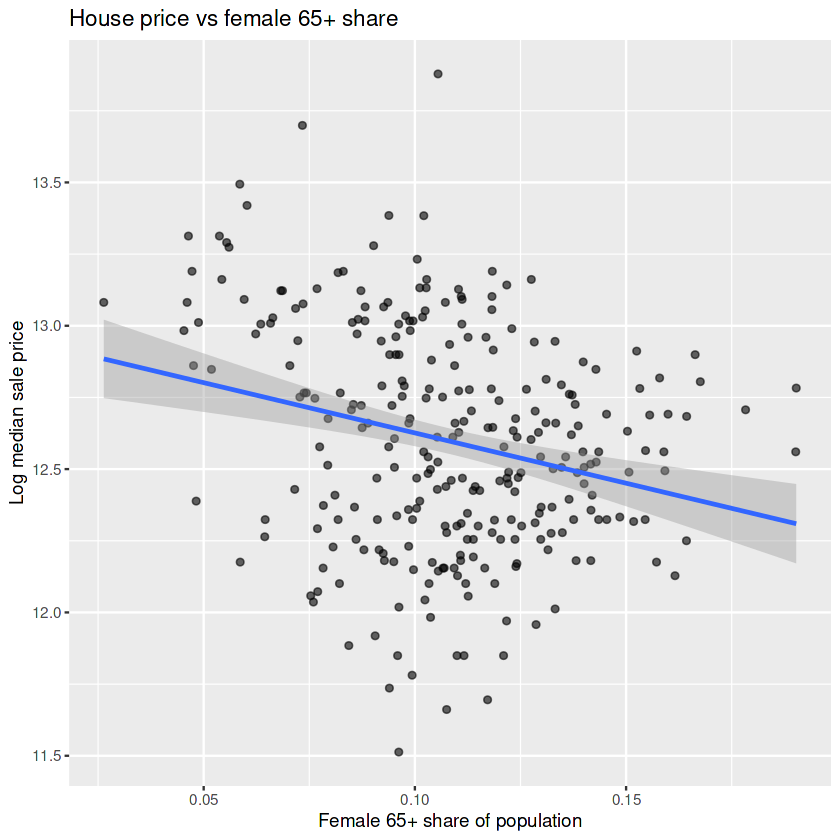

In [52]:
# Female/male ratio is very close to 50:50 across areas, so might not explain house-price trends.
# Older group sex by age comparison to house price could be more useful

sex_house_lad = lad_iht_estimates %>%
  mutate(
    female_pop = rowSums(across(matches("^F[0-9]+$")), na.rm = TRUE),
    male_pop   = rowSums(across(matches("^M[0-9]+$")), na.rm = TRUE),

    female_share = female_pop / population,
    male_share   = male_pop / population,

    female_65_plus = rowSums(across(matches("^F(6[5-9]|[7-9][0-9]|1[0-9][0-9])$")), na.rm = TRUE),
    male_65_plus   = rowSums(across(matches("^M(6[5-9]|[7-9][0-9]|1[0-9][0-9])$")), na.rm = TRUE),

    female_65_plus_share = female_65_plus / population,
    male_65_plus_share   = male_65_plus / population
  ) %>%
  left_join(
    housing_lad %>%
      select(lad_code, median_latest_sale_price),
    by = "lad_code"
  ) %>%
  mutate(
    log_median_sale_price = log(median_latest_sale_price)
  )

#Plot with Log

ggplot(sex_house_lad, aes(x = female_65_plus_share, y = log_median_sale_price)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "House price vs female 65+ share",
    x = "Female 65+ share of population",
    y = "Log median sale price"
  )

Chart Summary:

There is a moderate negative relationship between house prices and the female 65+ share of the population.
At the Local Authority District level, areas with a larger share of older women tend to have lower median house prices.

However, this does not mean that older women poplation is causing the lower prices.
But it is more likely that areas with a higher share of older woman are areas that have an
older population overall (higher lifespan for women) and this results to less people working and more retired residents.



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 11 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`).”


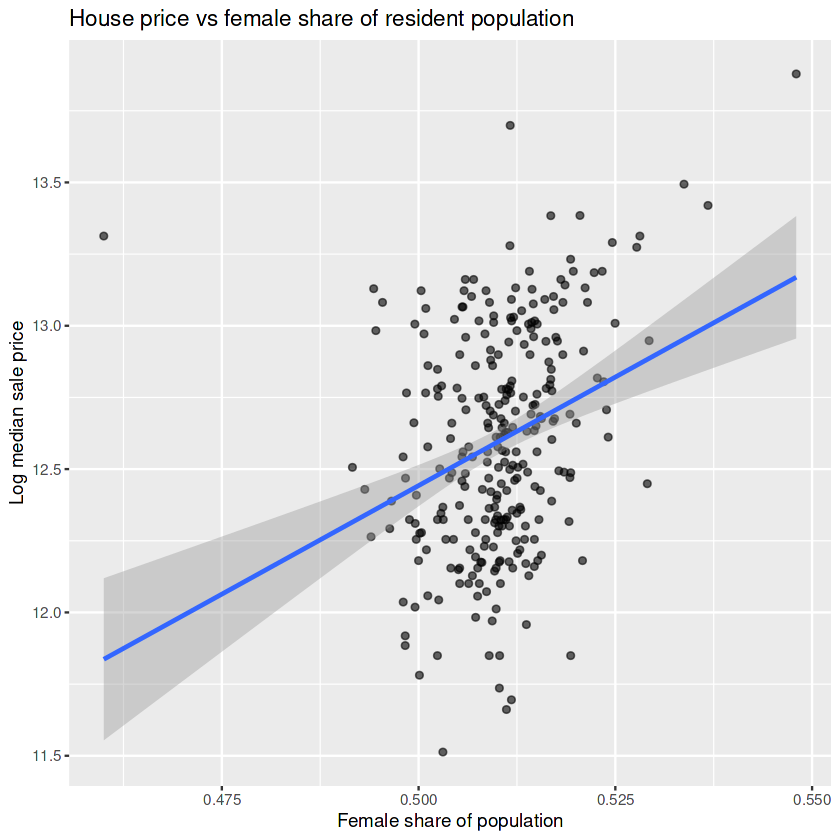

In [53]:
#Plot just female share regardless of age, to see if it also have a moderate negative relationship

ggplot(sex_house_lad, aes(x = female_share, y = log_median_sale_price)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "House price vs female share of resident population",
    x = "Female share of population",
    y = "Log median sale price"
  )

Chart Summary:

There is a moderate positive relationship between house price and female share of the resident population.

This is the opposite effect when compare to older women, which suggest that sex is no a very good indicator of house price or property wealth.

Overall, female population share has only a mild positive association with house price which reverses with the older population. However, the relationship is weak, suggesting that wider demographic factors might be contributing more than sex.